In [1]:
!pip install yfinance pandas numpy scipy matplotlib seaborn dtaidistance scikit-learn

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from dtaidistance import dtw
import warnings
warnings.filterwarnings('ignore')

In [3]:
# --- Configuration ---
BENCHMARK = '^IXIC'
RISK_FREE_RATE = 0.045
START_DATE = '2014-01-01'
END_DATE = '2024-01-01'
ROLLING_WINDOW = 52
N_CLUSTERS = 5  # Target number of clusters
MIN_HISTORY = 400 # Minimum weeks of data required per stock

In [4]:
# Retrieving NASDAQ tickers (100)
nasdaq_100_tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'TSLA', 'GOOGL', 'GOOG', 'AVGO', 'ASML',
    'COST', 'NFLX', 'AZN', 'AMD', 'PEP', 'ADBE', 'LIN', 'QCOM', 'INTU', 'AMAT',
    'CSCO', 'TXN', 'AMGN', 'ISRG', 'MU', 'HON', 'BKNG', 'VRTX', 'REGN', 'ADI',
    'PANW', 'LRCX', 'GILD', 'SBUX', 'MDLZ', 'ADP', 'KLAC', 'MELI', 'SNPS', 'CDNS',
    'CRWD', 'ABNB', 'MAR', 'ORLY', 'CTAS', 'MNST', 'FTNT', 'WDAY', 'MRVL', 'PCAR',
    'CPRT', 'ROST', 'PAYX', 'DXCM', 'KDP', 'ODFL', 'FAST', 'IDXX', 'MCHP', 'BIIB',
    'EA', 'GEHC', 'EXC', 'KHC', 'VRSK', 'ON', 'XEL', 'CTSH', 'DLTR', 'CCEP',
    'CSGP', 'ANSS', 'FANG', 'BKR', 'CDW', 'TEAM', 'DDOG', 'SMCI', 'ILMN', 'WBD',
    'ZS', 'ALGN', 'ENPH', 'GFS', 'MDB', 'LCID', 'RIVN', 'SIRI', 'MTCH', 'PARA'
]

# Downloading benchmark data
print('Downloading NASDAQ benchmark data...')
benchmark_raw = yf.download(BENCHMARK, start=START_DATE, end=END_DATE, interval='1wk')
benchmark_prices = benchmark_raw['Close'].squeeze()
benchmark_returns = np.log(benchmark_prices / benchmark_prices.shift(1)).dropna()

print(f'Benchmark data downloaded: {len(benchmark_returns)} weekly observations')
print(f'Date range: {benchmark_returns.index[0].date()} to {benchmark_returns.index[-1].date()}')

[*********************100%***********************]  1 of 1 completed

Benchmark data downloaded: 521 weekly observations
Date range: 2014-01-08 to 2023-12-27


In [5]:
# Downloading all stock price data
print(f'Downloading price data for {len(nasdaq_100_tickers)} stocks...')

raw_data = yf.download(
    nasdaq_100_tickers,
    start=START_DATE,
    end=END_DATE,
    interval='1wk',
    auto_adjust=True,
    progress=True
)

# Extracting closing prices
price_data = raw_data['Close']

# Resample to weekly frequency (Wednesday) to match Vitulano's methodology 
price_data = price_data.resample('W-WED').last()

# Drop any rows where all values are NaN (holidays/gaps)
price_data = price_data.dropna(how='all')

# Dropping stocks with insufficient history
valid_stocks = price_data.columns[price_data.count() >= MIN_HISTORY].tolist()
price_data = price_data[valid_stocks]

# Fill any small gaps, then drop any remaining NaNs
price_data = price_data.ffill().dropna(axis=1)

print(f'\nStocks with sufficient history: {len(price_data.columns)}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')
print(f'Total weekly observations per stocks: {len(price_data)}')

# DataFrame Corrections
print(price_data.shape)
print(price_data.head())

# Removing any duplicate dates yfinance may have introduced
price_data = price_data[~price_data.index.duplicated(keep='first')]
price_data = price_data.sort_index()

print(f'Shape after reduction: {price_data.shape}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
$ANSS: possibly delisted; no timezone found      ]  51 of 90 completed
[**********************67%*******                ]  60 of 90 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
$PARA: possibly delisted; no timezone found      ]  63 of 90 completed
[*********************100%***********************]  90 of 90 completed

2 Failed downloads:
['ANSS', 'PARA']: possibly delisted; no timezone found



Stocks with sufficient history: 77
Date range: 2014-01-01 to 2023-12-27
Total weekly observations per stocks: 522
(522, 77)
Ticker           AAPL       ADBE        ADI        ADP       ALGN       AMAT  \
Date                                                                           
2014-01-01  16.719622  58.970001  38.269943  54.069008  61.360001  14.819964   
2014-01-08  16.916218  60.369999  38.362541  53.513466  60.400002  15.041800   
2014-01-15  16.999187  60.849998  38.570904  53.761108  62.669998  15.024734   
2014-01-22  15.681222  59.110001  37.436462  51.559006  57.470001  14.290985   
2014-01-29  15.752117  59.720001  36.803646  50.166782  55.230000  14.316585   

Ticker       AMD       AMGN       AMZN       ASML  ...       SIRI   SMCI  \
Date                                               ...                     
2014-01-01  4.18  81.985931  19.901501  79.165085  ...  30.918938  1.677   
2014-01-08  4.30  82.894287  19.877001  80.759201  ...  29.397011  1.703   
2014-01-15

In [6]:
# Calculate Log Returns for all stocks and benchmarks
stock_returns = np.log(price_data / price_data.shift(1)).dropna()

# Align benchmark returns to match stock return dates exactly 
benchmark_returns_aligned = benchmark_returns.reindex(stock_returns.index).ffill().dropna()

# Making both the same date range
common_dates = stock_returns.index.intersection(benchmark_returns_aligned.index)
stock_returns = stock_returns.loc[common_dates]
benchmark_returns_aligned = benchmark_returns_aligned.loc[common_dates]

print(f'Stock returns shape: {stock_returns.shape}')
print(f'Benchmark returns shape: {benchmark_returns_aligned.shape}')
print(f'Date range: {stock_returns.index[0].date()} to {stock_returns.index[-1].date()}')
print(f'\nSample returns for AAPL (first 5 weeks):')
print(stock_returns['AAPL'].head())

Stock returns shape: (521, 77)
Benchmark returns shape: (521,)
Date range: 2014-01-08 to 2023-12-27

Sample returns for AAPL (first 5 weeks):
Date
2014-01-08    0.011690
2014-01-15    0.004893
2014-01-22   -0.080702
2014-01-29    0.004511
2014-02-05    0.052025
Freq: W-WED, Name: AAPL, dtype: float64


In [7]:
# Calculating Rolling Information Ratio for each stock
def calculate_rolling_ir(stock_returns, benchmark_returns, window=ROLLING_WINDOW):
    '''
    Information Ratio: (Stock Return - Benchmark Return) / Tracking Error

    - Active Return = Stock Return - Benchmark Return (exvess over benchmark)
    - Tracking Error = Rolling standard deviation of active returns
    - Annualized by multiplying by sqrt(52)
    '''

    # Calculating active returns (excess over benchmark)
    active_returns = stock_returns.subtract(benchmark_returns, axis=0)

    # Calculating rolling annualized active return (numerator)
    rolling_active_return = active_returns.rolling(window=window).mean() * window

    # Calculating rolling annualized tracking error (denominator)
    rolling_tracking_error = active_returns.rolling(window=window).std() * np.sqrt(window)

    # Calculating Information Ratio
    ir = rolling_active_return / rolling_tracking_error

    return ir

print('Calculating rolling Information Ratio...')
ir_data = calculate_rolling_ir(stock_returns, benchmark_returns_aligned)

# Drop the first 52 rows 
ir_data = ir_data.dropna(how='all')

# Drop any stocks that still have NaN values
ir_data = ir_data.dropna(axis=1)

print(f'Information Ratio matrix shape: {ir_data.shape}')
print(f'Date range: {ir_data.index[0].date()} to {ir_data.index[-1].date()}')
print(f'Stocks remaining: {len(ir_data.columns)}')
print(f'\nSample IR for AAPL (first 5 values):')
print(ir_data['AAPL'].head())

Calculating rolling Information Ratio...
Information Ratio matrix shape: (470, 77)
Date range: 2014-12-31 to 2023-12-27
Stocks remaining: 77

Sample IR for AAPL (first 5 values):
Date
2014-12-31    1.216020
2015-01-07    1.298171
2015-01-14    1.259767
2015-01-21    1.563526
2015-01-28    1.737918
Freq: W-WED, Name: AAPL, dtype: float64


In [8]:
# Building DTW Distance Matrix
print('Building DTW distance matrix...')
print('This is the most computationally expensive step, so it may take 5-10 minutes...')
print(f'Computing {len(ir_data.columns)} x {len(ir_data.columns)} distance matrix\n')

# Convert IR data to Numpy array
ir_matrix = ir_data.values.T # Transpose so shape is (n_stocks, n_timepoints)

# Normalizing each stock's IR series to have a mean of 0 and std of 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
ir_matrix_scaled = scaler.fit_transform(ir_matrix.T).T

# Computing DTW distance matrix
n_stocks = ir_matrix_scaled.shape[0]
distance_matrix = np.zeros((n_stocks, n_stocks))

for i in range(n_stocks):
    for j in range(i+1, n_stocks):
        dist = dtw.distance(ir_matrix_scaled[i], ir_matrix_scaled[j])
        distance_matrix[i, j] = dist
        distance_matrix[j, i] = dist

    if i % 10 == 0:
        print(f'Progress: {i}/{n_stocks} stocks processed...')

print(f'\nDTW distance matrix complete!')
print(f'Distance matrix shape: {distance_matrix.shape}')
print(f'Sample distances (first 3x3):')
print(np.round(distance_matrix[:3,:3], 4))

Building DTW distance matrix...
This is the most computationally expensive step, so it may take 5-10 minutes...
Computing 77 x 77 distance matrix

Progress: 0/77 stocks processed...
Progress: 10/77 stocks processed...
Progress: 20/77 stocks processed...
Progress: 30/77 stocks processed...
Progress: 40/77 stocks processed...
Progress: 50/77 stocks processed...
Progress: 60/77 stocks processed...
Progress: 70/77 stocks processed...

DTW distance matrix complete!
Distance matrix shape: (77, 77)
Sample distances (first 3x3):
[[ 0.     11.8562 10.4278]
 [11.8562  0.      9.8956]
 [10.4278  9.8956  0.    ]]


In [9]:
# Running Hierarchical Clustering
print('Running hierarchical clustering...')

# Converting distance matrix to condensed matrix 
condensed_distances = squareform(distance_matrix)

# Running hierarchical clustering using Ward.D2 linkage
linkage_matrix = linkage(condensed_distances, method='ward')

# Cutting the tree at k=5 clusters
cluster_labels = fcluster(linkage_matrix, t=N_CLUSTERS, criterion='maxclust')

# Mapping cluster labels back to stock tickers
cluster_assignments = pd.Series(cluster_labels, index=ir_data.columns, name='Cluster')

# Summary of Cluster sizes
cluster_sizes = cluster_assignments.value_counts().sort_index()

print(f'Clustering complete!')
print(f'\nCluster sizes:')
for cluster_num, size in cluster_sizes.items():
    print(f' Cluster {cluster_num}: {size} stocks')

print(f'\nCluster assignments (first 20 stocks):')
print(cluster_assignments.head(20))

Running hierarchical clustering...
Clustering complete!

Cluster sizes:
 Cluster 1: 23 stocks
 Cluster 2: 10 stocks
 Cluster 3: 25 stocks
 Cluster 4: 3 stocks
 Cluster 5: 16 stocks

Cluster assignments (first 20 stocks):
Ticker
AAPL    5
ADBE    1
ADI     3
ADP     3
ALGN    1
AMAT    1
AMD     2
AMGN    3
AMZN    2
ASML    1
AVGO    4
AZN     3
BIIB    3
BKNG    2
BKR     3
CCEP    1
CDNS    1
CDW     3
COST    3
CPRT    2
Name: Cluster, dtype: int32


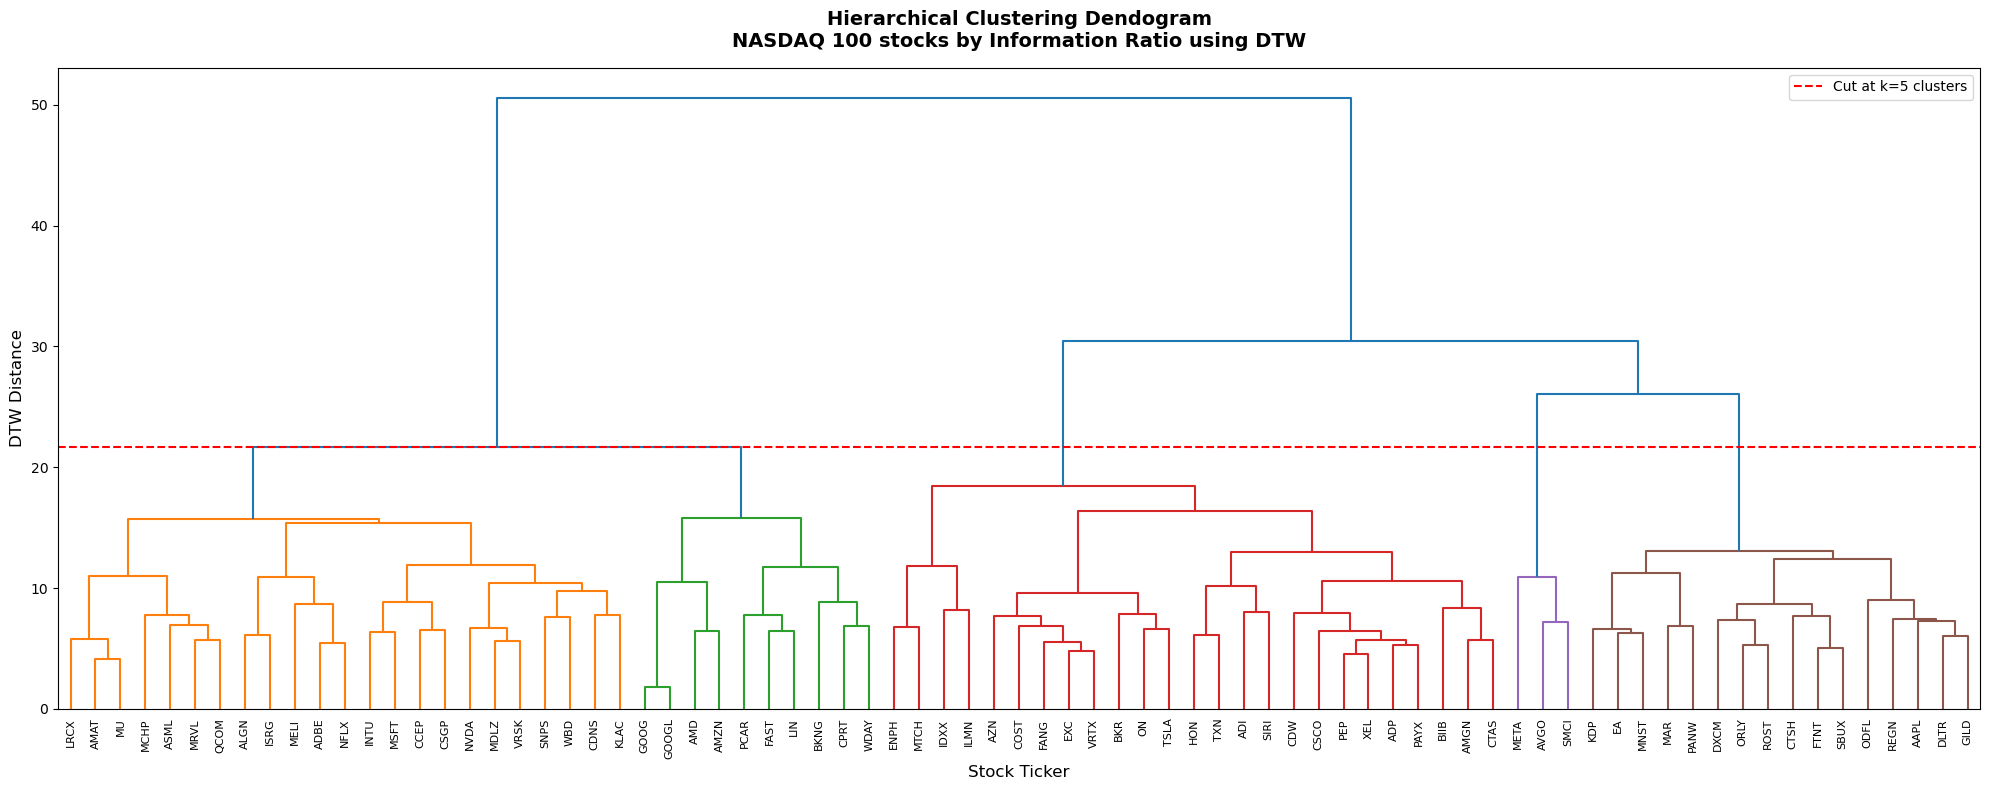

Cut height for k=5 clusters: 21.6588


In [11]:
# Visualizing the dendogram
fig, ax = plt.subplots(figsize=(20, 8))

color_threshold = linkage_matrix[-(N_CLUSTERS-1),2]

dendrogram(
    linkage_matrix,
    labels=ir_data.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=color_threshold,
    ax=ax
)

ax.set_title(
    'Hierarchical Clustering Dendogram\nNASDAQ 100 stocks by Information Ratio using DTW',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Stock Ticker', fontsize=12)
ax.set_ylabel('DTW Distance', fontsize=12)
ax.axhline(
    y=color_threshold,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Cut at k={N_CLUSTERS} clusters'
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('dendogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Cut height for k={N_CLUSTERS} clusters: {color_threshold:.4f}')


Calculating Cluster Validation Indices...
Testing k=2 through k=7 to validate optimal cluster number

k=2: Silhouette=0.0854 CH=7.80 DB=3.0533
k=3: Silhouette=0.0400 CH=5.64 DB=3.3182
k=4: Silhouette=0.0267 CH=4.44 DB=2.9803
k=5: Silhouette=0.0157 CH=3.67 DB=3.5720
k=6: Silhouette=0.0136 CH=3.89 DB=3.3208
k=7: Silhouette=-0.0000 CH=3.69 DB=3.1223


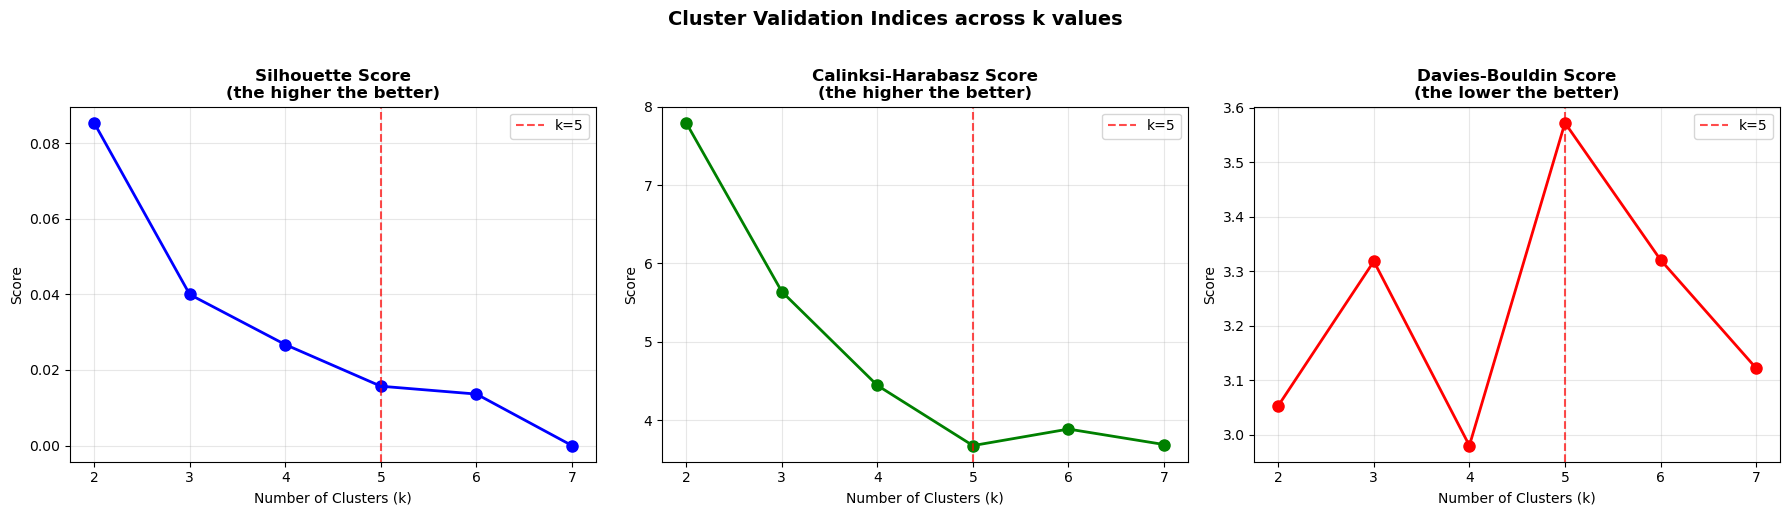


Best k by Silhouette: k=2
Best k by CH index: k=2
Best k by DB index: k=4


In [21]:
# CLuster Validation Indices (CVI's)
print('Calculating Cluster Validation Indices...')
print('Testing k=2 through k=7 to validate optimal cluster number\n')

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X = ir_matrix_scaled

k_range = range(2,8)
silhouette_scores = []
ch_scores = []
db_scores = []

for k in k_range:
    # Getting cluster labels for this k
    labels = fcluster(linkage_matrix, t=k, criterion='maxclust')

    # Silhouette Score - The higher the better
    sil = silhouette_score(X, labels, metric='euclidean')
    silhouette_scores.append(sil)

    # CH Score - the higher the better
    ch = calinski_harabasz_score(X, labels)
    ch_scores.append(ch)

    # DB Score - the lower the better
    db = davies_bouldin_score(X, labels)
    db_scores.append(db)

    print(f'k={k}: Silhouette={sil:.4f} CH={ch:.2f} DB={db:.4f}')

# Plotting the CVI's
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Silhouette
axes[0].plot(list(k_range),  silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Silhouette Score\n(the higher the better)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Score')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calinski-Harabasz
axes[1].plot(list(k_range), ch_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Calinksi-Harabasz Score\n(the higher the better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin 
axes[2].plot(list(k_range), db_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Score\n(the lower the better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Score')
axes[2].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Cluster Validation Indices across k values',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cvi_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f'\nBest k by Silhouette: k={k_range[silhouette_scores.index(max(silhouette_scores))]}')
print(f'Best k by CH index: k={k_range[ch_scores.index(max(ch_scores))]}')
print(f'Best k by DB index: k={k_range[db_scores.index(min(db_scores))]}')




Cluster 1 (23 stocks):
ADBE, ALGN, AMAT, ASML, CCEP, CDNS, CSGP, INTU, ISRG, KLAC, LRCX, MCHP, MDLZ, MELI, MRVL, MSFT, MU, NFLX, NVDA, QCOM, SNPS, VRSK, WBD

Cluster 2 (10 stocks):
AMD, AMZN, BKNG, CPRT, FAST, GOOG, GOOGL, LIN, PCAR, WDAY

Cluster 3 (25 stocks):
ADI, ADP, AMGN, AZN, BIIB, BKR, CDW, COST, CSCO, CTAS, ENPH, EXC, FANG, HON, IDXX, ILMN, MTCH, ON, PAYX, PEP, SIRI, TSLA, TXN, VRTX, XEL

Cluster 4 (3 stocks):
AVGO, META, SMCI

Cluster 5 (16 stocks):
AAPL, CTSH, DLTR, DXCM, EA, FTNT, GILD, KDP, MAR, MNST, ODFL, ORLY, PANW, REGN, ROST, SBUX


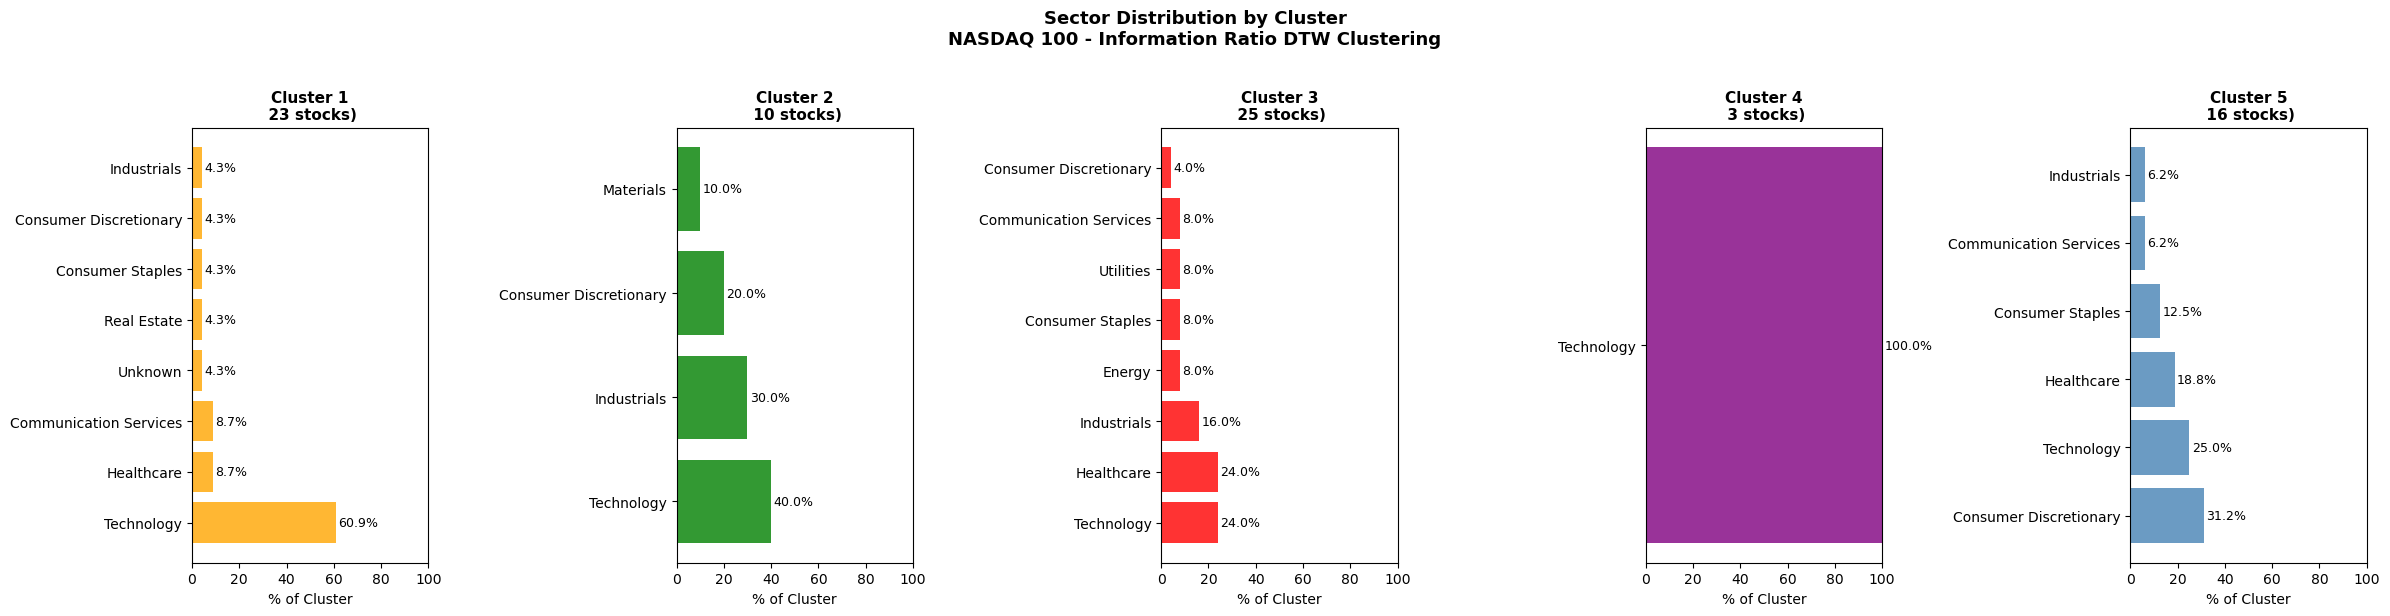

In [23]:
# Analyzing Cluster Compositions
sector_map = {
     'AAPL': 'Technology', 'MSFT': 'Technology', 'NVDA': 'Technology',
    'AMZN': 'Consumer Discretionary', 'META': 'Technology', 'TSLA': 'Consumer Discretionary',
    'GOOGL': 'Technology', 'GOOG': 'Technology', 'AVGO': 'Technology', 'ASML': 'Technology',
    'COST': 'Consumer Staples', 'NFLX': 'Communication Services', 'AMD': 'Technology',
    'PEP': 'Consumer Staples', 'ADBE': 'Technology', 'QCOM': 'Technology',
    'INTU': 'Technology', 'AMAT': 'Technology', 'CSCO': 'Technology', 'TXN': 'Technology',
    'AMGN': 'Healthcare', 'ISRG': 'Healthcare', 'MU': 'Technology', 'HON': 'Industrials',
    'BKNG': 'Consumer Discretionary', 'VRTX': 'Healthcare', 'REGN': 'Healthcare',
    'ADI': 'Technology', 'PANW': 'Technology', 'LRCX': 'Technology', 'GILD': 'Healthcare',
    'SBUX': 'Consumer Discretionary', 'MDLZ': 'Consumer Staples', 'ADP': 'Industrials',
    'KLAC': 'Technology', 'MELI': 'Consumer Discretionary', 'SNPS': 'Technology',
    'CDNS': 'Technology', 'CRWD': 'Technology', 'ABNB': 'Consumer Discretionary',
    'MAR': 'Consumer Discretionary', 'ORLY': 'Consumer Discretionary', 'CTAS': 'Industrials',
    'MNST': 'Consumer Staples', 'FTNT': 'Technology', 'WDAY': 'Technology',
    'MRVL': 'Technology', 'PCAR': 'Industrials', 'CPRT': 'Industrials',
    'ROST': 'Consumer Discretionary', 'PAYX': 'Industrials', 'DXCM': 'Healthcare',
    'KDP': 'Consumer Staples', 'ODFL': 'Industrials', 'FAST': 'Industrials',
    'IDXX': 'Healthcare', 'MCHP': 'Technology', 'BIIB': 'Healthcare',
    'EA': 'Communication Services', 'GEHC': 'Healthcare', 'EXC': 'Utilities',
    'KHC': 'Consumer Staples', 'VRSK': 'Industrials', 'ON': 'Technology',
    'XEL': 'Utilities', 'CTSH': 'Technology', 'DLTR': 'Consumer Discretionary',
    'CSGP': 'Real Estate', 'FANG': 'Energy', 'BKR': 'Energy',
    'CDW': 'Technology', 'TEAM': 'Technology', 'DDOG': 'Technology',
    'SMCI': 'Technology', 'ILMN': 'Healthcare', 'WBD': 'Communication Services',
    'ZS': 'Technology', 'ALGN': 'Healthcare', 'ENPH': 'Technology',
    'GFS': 'Technology', 'MDB': 'Technology', 'SIRI': 'Communication Services',
    'MTCH': 'Communication Services', 'LIN': 'Materials', 'AZN': 'Healthcare',
    'MELI': 'Consumer Discretionary'
}

# Building a Summary DataFrame
cluster_df = pd.DataFrame({
    'Ticker': cluster_assignments.index,
    'Cluster': cluster_assignments.values,
    'Sector': [sector_map.get(t, 'Unknown') for t in cluster_assignments.index]
})

# Print stocks in each cluster
for c in range(1, N_CLUSTERS + 1):
    tickers = cluster_df[cluster_df['Cluster'] == c]['Ticker'].tolist()
    print(f"\nCluster {c} ({len(tickers)} stocks):")
    print(', '.join(tickers))

# Plotting Sector Distribution by Cluster
fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(24,6))

colors = ['orange', 'green', 'red', 'purple', 'steelblue']

for c in range(1, N_CLUSTERS + 1):
    cluster_stocks = cluster_df[cluster_df['Cluster'] == c]
    sector_counts = cluster_stocks['Sector'].value_counts()
    sector_pct = (sector_counts / len(cluster_stocks) * 100).round(1)

    axes[c-1].barh(sector_pct.index, sector_pct.values, color=colors[c-1], alpha=0.8)
    axes[c-1].set_title(f'Cluster {c}\n {len(cluster_stocks)} stocks)' ,
                        fontweight='bold', fontsize=11)
    axes[c-1].set_xlabel('% of Cluster')
    axes[c-1].set_xlim(0,100)

    for i, (idx, val) in enumerate(sector_pct.items()):
        axes[c-1].text(val + 1, i, f'{val}%', va='center', fontsize=9)

plt.suptitle('Sector Distribution by Cluster\nNASDAQ 100 - Information Ratio DTW Clustering', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sector_distribution.png', dpi=150, bbox_inches='tight')
plt.show() 

Plotting average IR dynamics by cluster...


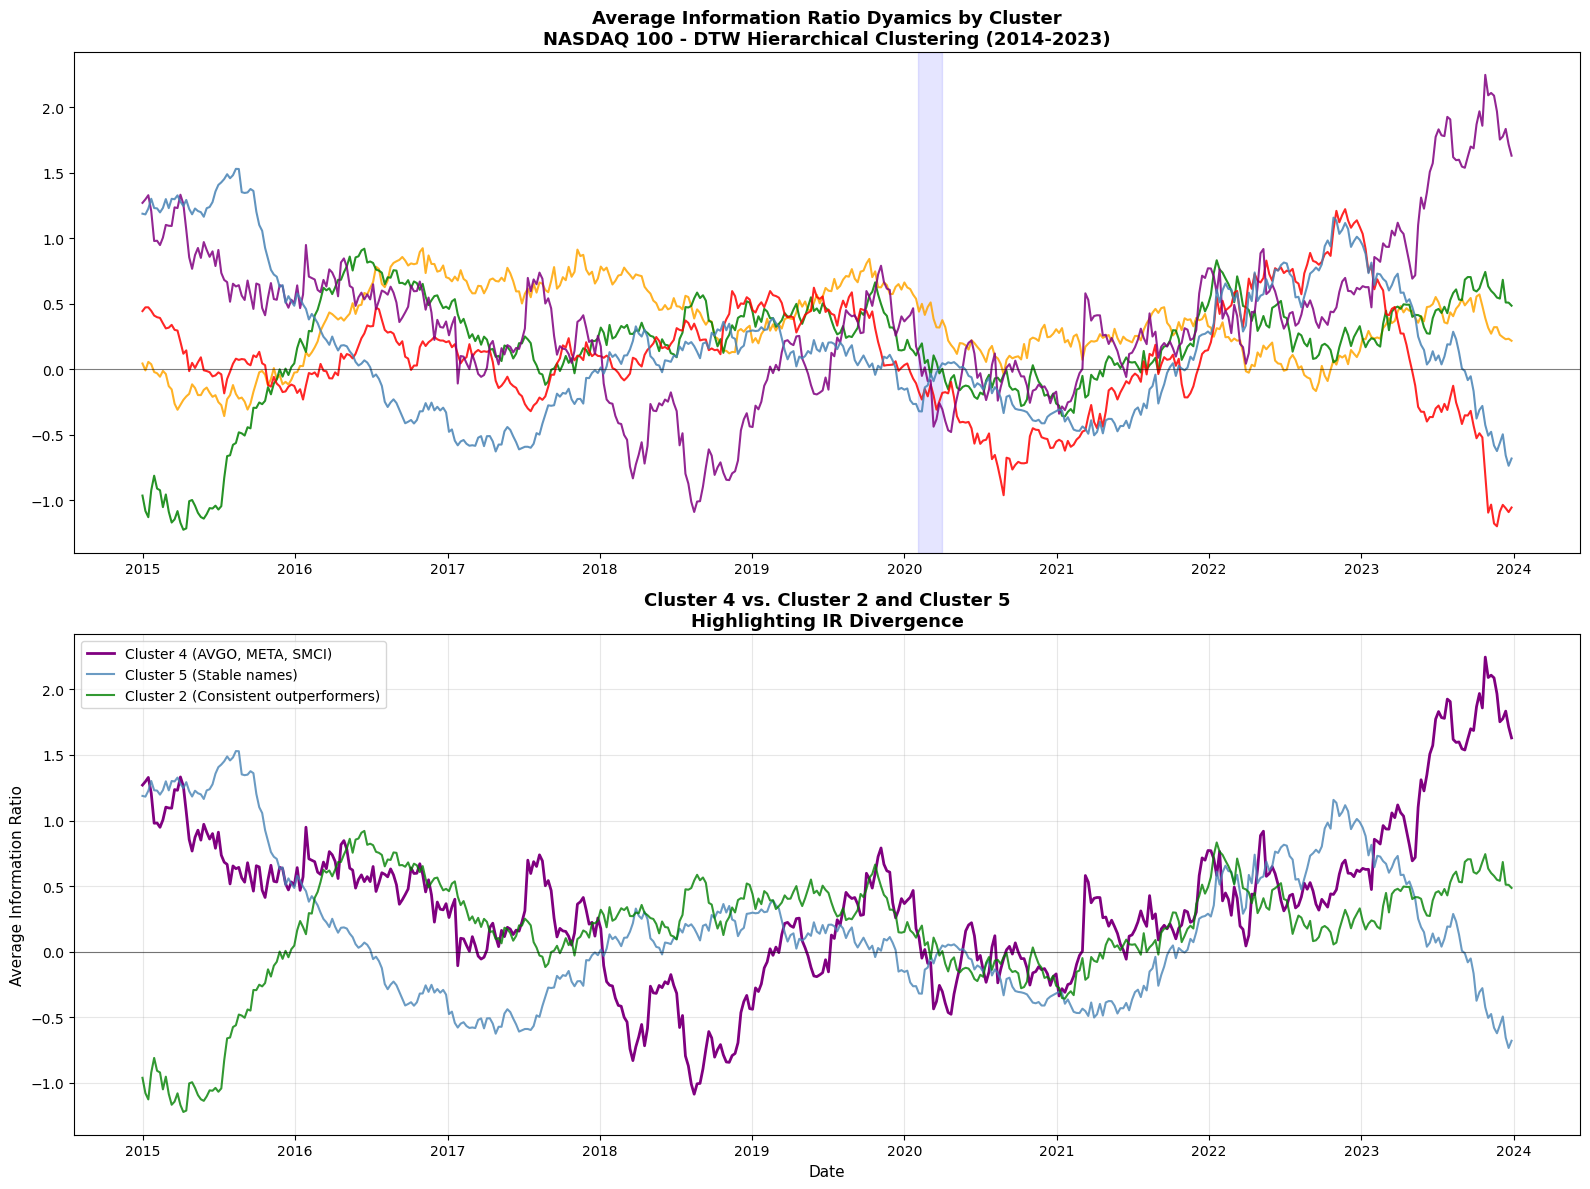


Average IR by cluster (full period):
Cluster 1    0.3479
Cluster 2    0.1745
Cluster 3    0.0868
Cluster 4    0.3636
Cluster 5    0.1679
dtype: float64

IR Volatility by cluster (std of average IR):
Cluster 1    0.2861
Cluster 2    0.4248
Cluster 3    0.4274
Cluster 4    0.5881
Cluster 5    0.5297
dtype: float64


In [27]:
# Plotting Average Rolling IR Dynamics by Cluster
print('Plotting average IR dynamics by cluster...')

# Calculating average IR time series for each cluster
cluster_ir_means={}

for c in range(1, N_CLUSTERS +1):
    # Get tickers belonging to this cluster
    cluster_tickers = cluster_df[cluster_df['Cluster'] == c]['Ticker'].tolist()

    # Filter to only tickers that exist in ir_data
    valid_tickers = [t for t in cluster_tickers if t in ir_data.columns]

    # Calcuate mean IR across all stocks in cluster at each point in time
    cluster_ir_means[c] = ir_data[valid_tickers].mean(axis=1)

# Converting to DataFrame
cluster_ir_df = pd.DataFrame(cluster_ir_means)
cluster_ir_df.columns = [f'Cluster {c}' for c in range(1, N_CLUSTERS + 1)]

# Plotting
colors = ['orange', 'green', 'red', 'purple', 'steelblue']

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1 (All Cluster together)
for c in range(1, N_CLUSTERS + 1):
    axes[0].plot(
        cluster_ir_df.index,
        cluster_ir_df[f'Cluster {c}'],
        color=colors[c-1],
        linewidth=1.5,
        label=f'Cluster {c}',
        alpha=0.85
    )
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[0].set_title(
    'Average Information Ratio Dyamics by Cluster\nNASDAQ 100 - DTW Hierarchical Clustering (2014-2023)',
    fontsize=13, fontweight='bold'
)

# Add shading for key market events
axes[0].axvspan(
    pd.Timestamp('2020-02-02'), pd.Timestamp('2020-04-01'),
    alpha=0.10, color='blue', label='Rate Hike Period'
)

# Plot 2 - Cluster 4 isolated vs. others
axes[1].plot(
    cluster_ir_df.index,
    cluster_ir_df['Cluster 4'],
    color='purple',
    linewidth=2,
    label='Cluster 4 (AVGO, META, SMCI)',
)
axes[1].plot(
    cluster_ir_df.index,
    cluster_ir_df['Cluster 5'],
    color='steelblue',
    linewidth=1.5,
    label='Cluster 5 (Stable names)',
    alpha=0.8
)
axes[1].plot(
    cluster_ir_df.index,
    cluster_ir_df['Cluster 2'],
    color='green',
    linewidth=1.5,
    label='Cluster 2 (Consistent outperformers)',
    alpha=0.8
)

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[1].set_title(
    'Cluster 4 vs. Cluster 2 and Cluster 5\nHighlighting IR Divergence',
    fontsize=13, fontweight='bold'
)
axes[1].set_ylabel('Average Information Ratio', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ir_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nAverage IR by cluster (full period):")
print(cluster_ir_df.mean().round(4))
print("\nIR Volatility by cluster (std of average IR):")
print(cluster_ir_df.std().round(4))

    